# Salary Distribution Analysis
**Data source:** `data/processed/salary_cleaned.csv`  
**Output:** `reports/figures/`

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid")

DATA   = Path("../data/processed/salary_cleaned.csv")
OUTDIR = Path("../reports/figures")
OUTDIR.mkdir(parents=True, exist_ok=True)

FIGSIZE = (12, 6)

Matplotlib is building the font cache; this may take a moment.


## Step 1 — Data Preparation

In [6]:
def prepare_salary_data(df: pd.DataFrame) -> pd.DataFrame:
    """Clean and normalise salary data for analysis.

    Steps
    -----
    1. Drop rows where both min_salary and max_salary are null.
    2. Convert USD → VND using a fixed FX rate.
       FX assumption: 1 USD = 25,000 VND (approximate rate, Aug 2023).
       This is a static assumption for analysis purposes only.
    3. Convert VND values to triệu (millions) for readability.
    4. Compute mid_salary as the representative point estimate.
    5. Remove statistical outliers (mid_salary > 200 triệu VND).
    """
    USD_TO_VND = 25_000  # FX rate assumption: 1 USD = 25,000 VND, Aug 2023

    out = df.copy()

    # ── 1. Drop rows with no salary information ───────────────────────────
    before = len(out)
    out = out.dropna(subset=["min_salary", "max_salary"], how="all")
    print(f"Dropped {before - len(out):,} rows with no salary → {len(out):,} remaining")

    # ── 2. Unify currency: USD → VND ─────────────────────────────────────
    usd_mask = out["salary_unit"] == "USD"
    out.loc[usd_mask, "min_salary"] = out.loc[usd_mask, "min_salary"] * USD_TO_VND
    out.loc[usd_mask, "max_salary"] = out.loc[usd_mask, "max_salary"] * USD_TO_VND
    out.loc[usd_mask, "salary_unit"] = "VND"
    print(f"Converted {usd_mask.sum():,} USD rows to VND (rate: 1 USD = {USD_TO_VND:,} VND)")

    # ── 3. Scale to triệu (millions) ─────────────────────────────────────
    out["min_salary"] = out["min_salary"] / 1_000_000
    out["max_salary"] = out["max_salary"] / 1_000_000

    # ── 4. Compute mid_salary ─────────────────────────────────────────────
    both_avail = out["min_salary"].notna() & out["max_salary"].notna()
    out["mid_salary"] = None
    out.loc[both_avail, "mid_salary"] = (
        out.loc[both_avail, "min_salary"] + out.loc[both_avail, "max_salary"]
    ) / 2
    out.loc[out["min_salary"].notna() & out["max_salary"].isna(), "mid_salary"] = \
        out.loc[out["min_salary"].notna() & out["max_salary"].isna(), "min_salary"]
    out.loc[out["max_salary"].notna() & out["min_salary"].isna(), "mid_salary"] = \
        out.loc[out["max_salary"].notna() & out["min_salary"].isna(), "max_salary"]
    out["mid_salary"] = pd.to_numeric(out["mid_salary"])

    # ── 5. Remove outliers ────────────────────────────────────────────────
    OUTLIER_CAP = 200  # triệu VND
    outliers = out["mid_salary"] > OUTLIER_CAP
    print(f"Dropping {outliers.sum():,} outlier rows (mid_salary > {OUTLIER_CAP} triệu)")
    out = out[~outliers]

    print(f"Final dataset: {len(out):,} rows")
    return out


raw = pd.read_csv(DATA)
df  = prepare_salary_data(raw)
df[["job_role_category", "mid_salary", "min_salary", "max_salary", "salary_unit"]].head()

Dropped 710 rows with no salary → 1,223 remaining
Converted 257 USD rows to VND (rate: 1 USD = 25,000 VND)
Dropping 3 outlier rows (mid_salary > 200 triệu)
Final dataset: 1,220 rows


,job_role_category,mid_salary,min_salary,max_salary,salary_unit
0,Business Analysis,15.0,10.0,20.0,VND
1,Software Development,15.0,10.0,20.0,VND
3,Project & Product Management,35.0,NaN,35.0,VND
4,DevOps & Cloud,50.0,NaN,50.0,VND
5,Software Development,15.0,12.0,18.0,VND


## Plot 1 — Box Plot: Salary Distribution by Category

Saved → ../reports/figures/salary_boxplot.png


/var/folders/cp/7wlkvy650_db46dkk1wj6qv80000gn/T/ipykernel_99371/3809707930.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


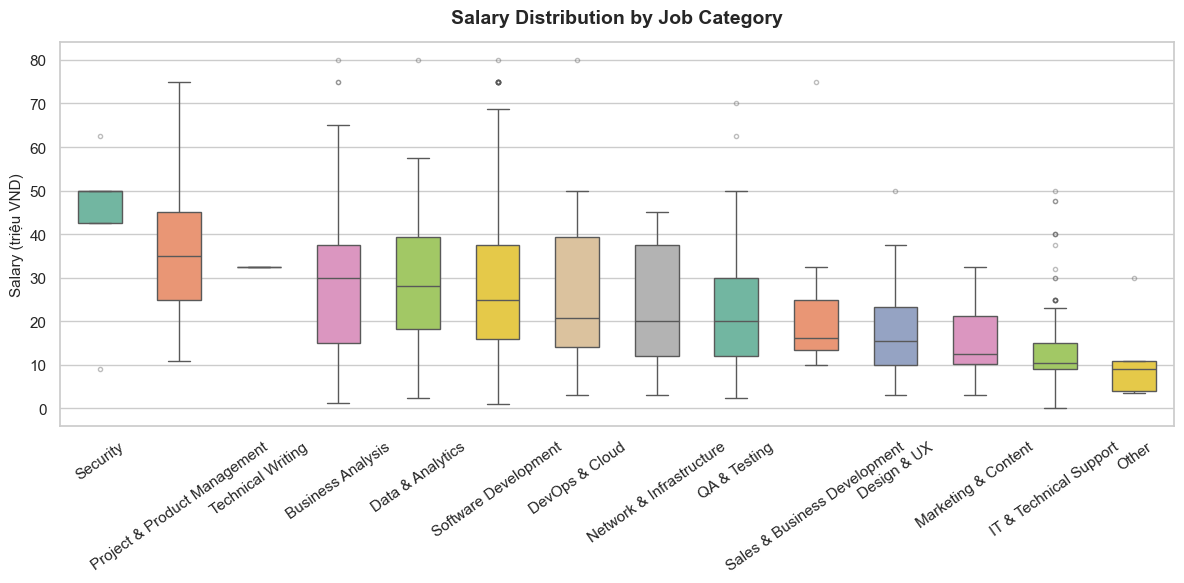

In [7]:
cat_order = (
    df.groupby("job_role_category")["mid_salary"]
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

fig, ax = plt.subplots(figsize=FIGSIZE)
sns.boxplot(
    data=df,
    x="job_role_category",
    y="mid_salary",
    order=cat_order,
    palette="Set2",
    width=0.55,
    flierprops=dict(marker="o", markersize=3, alpha=0.4),
    ax=ax,
)
ax.set_title("Salary Distribution by Job Category", fontsize=14, fontweight="bold", pad=14)
ax.set_xlabel("")
ax.set_ylabel("Salary (triệu VND)", fontsize=11)
ax.tick_params(axis="x", rotation=35)
plt.tight_layout()

out_path = OUTDIR / "salary_boxplot.png"
fig.savefig(out_path, dpi=150)
print(f"Saved → {out_path}")
plt.show()

## Plot 2 — Bar Chart: Median Salary by Category

Saved → ../reports/figures/salary_median_bar.png


/var/folders/cp/7wlkvy650_db46dkk1wj6qv80000gn/T/ipykernel_99371/1105455264.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


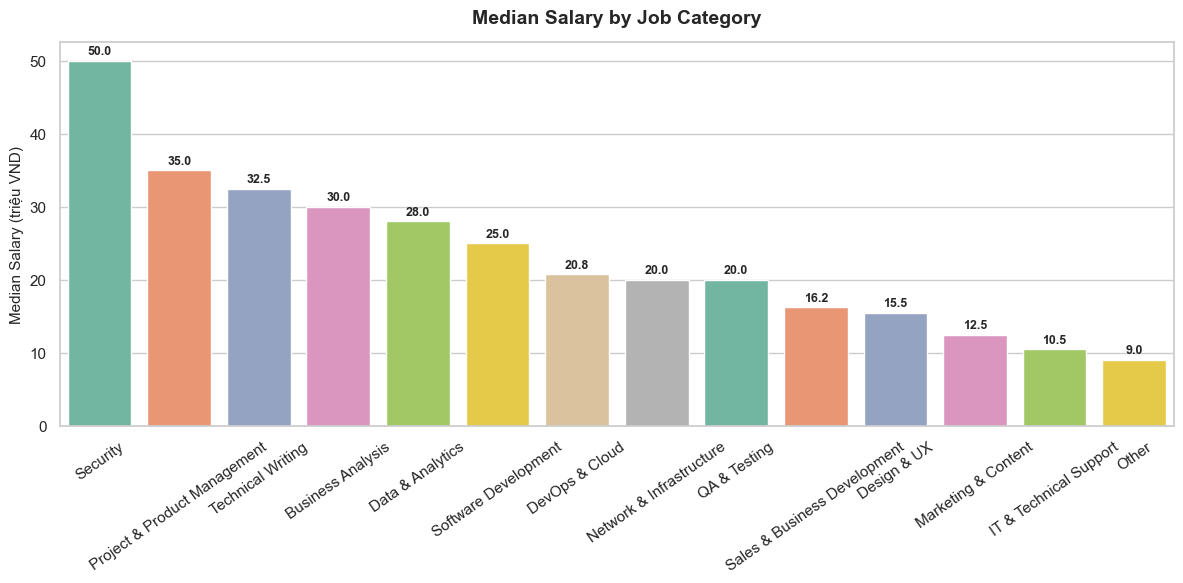

In [8]:
medians = (
    df.groupby("job_role_category")["mid_salary"]
    .median()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"mid_salary": "median_salary"})
)

fig, ax = plt.subplots(figsize=FIGSIZE)
bars = sns.barplot(
    data=medians,
    x="job_role_category",
    y="median_salary",
    palette="Set2",
    ax=ax,
)
for bar, val in zip(ax.patches, medians["median_salary"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{val:.1f}",
        ha="center", va="bottom", fontsize=9, fontweight="bold",
    )
ax.set_title("Median Salary by Job Category", fontsize=14, fontweight="bold", pad=14)
ax.set_xlabel("")
ax.set_ylabel("Median Salary (triệu VND)", fontsize=11)
ax.tick_params(axis="x", rotation=35)
plt.tight_layout()

out_path = OUTDIR / "salary_median_bar.png"
fig.savefig(out_path, dpi=150)
print(f"Saved → {out_path}")
plt.show()

## Plot 3 — KDE: Salary Distribution for Top 3 Categories

Saved → ../reports/figures/salary_kde_top3.png


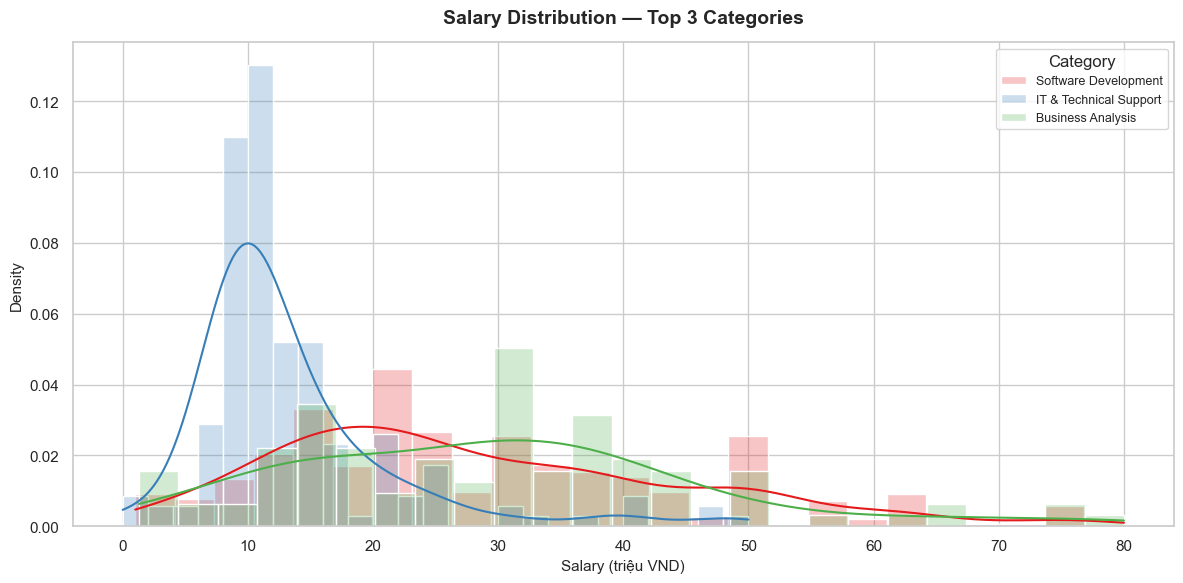

In [9]:
top3 = (
    df["job_role_category"].value_counts().head(3).index.tolist()
)
df_top3 = df[df["job_role_category"].isin(top3)]

fig, ax = plt.subplots(figsize=FIGSIZE)
palette = sns.color_palette("Set1", n_colors=3)

for cat, color in zip(top3, palette):
    subset = df_top3.loc[df_top3["job_role_category"] == cat, "mid_salary"].dropna()
    sns.histplot(
        subset, kde=True, stat="density",
        color=color, alpha=0.25, bins=25, ax=ax, label=cat,
    )

ax.set_title("Salary Distribution — Top 3 Categories", fontsize=14, fontweight="bold", pad=14)
ax.set_xlabel("Salary (triệu VND)", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.legend(title="Category", fontsize=9)
plt.tight_layout()

out_path = OUTDIR / "salary_kde_top3.png"
fig.savefig(out_path, dpi=150)
print(f"Saved → {out_path}")
plt.show()

## Plot 4 — Job Count vs Median Salary (dual axis)

In [ ]:
summary = (
    df.groupby("job_role_category")
    .agg(job_count=("mid_salary", "count"), median_salary=("mid_salary", "median"))
    .sort_values("job_count", ascending=False)
    .reset_index()
)

fig, ax1 = plt.subplots(figsize=FIGSIZE)
ax2 = ax1.twinx()

bar_color = sns.color_palette("Set2")[0]
line_color = sns.color_palette("Set1")[1]

ax1.bar(
    summary["job_role_category"], summary["job_count"],
    color=bar_color, alpha=0.75, label="Job count",
)
ax2.plot(
    summary["job_role_category"], summary["median_salary"],
    color=line_color, marker="o", linewidth=2, markersize=7, label="Median salary",
)

ax1.set_xlabel("")
ax1.set_ylabel("Job Count", color=bar_color, fontsize=11)
ax2.set_ylabel("Median Salary (triệu VND)", color=line_color, fontsize=11)
ax1.tick_params(axis="x", rotation=35)
ax1.tick_params(axis="y", labelcolor=bar_color)
ax2.tick_params(axis="y", labelcolor=line_color)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right", fontsize=9)

fig.suptitle("Job Count vs Median Salary by Category", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()

out_path = OUTDIR / "salary_count_vs_median.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"Saved → {out_path}")
plt.show()

## Summary

In [ ]:
summary_table = (
    df.groupby("job_role_category")["mid_salary"]
    .agg(["count", "median", "mean", "min", "max"])
    .rename(columns={
        "count":  "Jobs",
        "median": "Median (triệu)",
        "mean":   "Mean (triệu)",
        "min":    "Min (triệu)",
        "max":    "Max (triệu)",
    })
    .sort_values("Median (triệu)", ascending=False)
    .round(1)
)
summary_table

## Plot 5 — Heatmap: Job Distribution by Region × Category

In [ ]:
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
OUTDIR = Path("../reports/figures")
OUTDIR.mkdir(parents=True, exist_ok=True)

# ── Load & merge ──────────────────────────────────────────────────────────────
locs = pd.read_csv("../data/processed/job_locations.csv")
jobs = pd.read_csv("../data/processed/salary_cleaned.csv",
                   usecols=["job_id", "job_role_category"])
df_map = locs.merge(jobs, on="job_id", how="left")

# ── Filter: top cities by job count, drop generic "Toàn Quốc" / "Nước Ngoài" ─
EXCLUDE_CITIES = {"Toàn Quốc", "Nước Ngoài"}
TOP_N_CITIES   = 10
TOP_N_CATS     = 10

city_counts = (
    df_map.loc[~df_map["city"].isin(EXCLUDE_CITIES), "city"]
    .value_counts()
    .head(TOP_N_CITIES)
    .index.tolist()
)

cat_counts = (
    df_map["job_role_category"]
    .value_counts()
    .head(TOP_N_CATS)
    .index.tolist()
)

df_filt = df_map[
    df_map["city"].isin(city_counts) &
    df_map["job_role_category"].isin(cat_counts)
]

# ── Pivot: city × category → job count ───────────────────────────────────────
pivot = (
    df_filt.groupby(["city", "job_role_category"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=city_counts, columns=cat_counts, fill_value=0)
)

# ── Normalise rows → % of jobs in that city (highlight mix, not volume) ──────
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

# ── Plot 1: Raw count heatmap ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    pivot,
    annot=True, fmt="d",
    cmap="YlOrRd",
    linewidths=0.4,
    cbar_kws={"label": "Job count"},
    ax=ax,
)
ax.set_title("Job Distribution by Region × Category (Count)",
             fontsize=14, fontweight="bold", pad=14)
ax.set_xlabel("Job Category", fontsize=11)
ax.set_ylabel("City", fontsize=11)
ax.tick_params(axis="x", rotation=40, labelsize=9)
ax.tick_params(axis="y", rotation=0,  labelsize=10)
plt.tight_layout()
fig.savefig(OUTDIR / "heatmap_region_category_count.png", dpi=150)
plt.show()
print("Saved → heatmap_region_category_count.png")

# ── Plot 2: Row-normalised % heatmap (category mix per city) ─────────────────
fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    pivot_pct.round(1),
    annot=True, fmt=".1f",
    cmap="Blues",
    linewidths=0.4,
    cbar_kws={"label": "% of city's jobs"},
    ax=ax,
)
ax.set_title("Category Mix per City (% of city's total jobs)",
             fontsize=14, fontweight="bold", pad=14)
ax.set_xlabel("Job Category", fontsize=11)
ax.set_ylabel("City", fontsize=11)
ax.tick_params(axis="x", rotation=40, labelsize=9)
ax.tick_params(axis="y", rotation=0,  labelsize=10)
plt.tight_layout()
fig.savefig(OUTDIR / "heatmap_region_category_pct.png", dpi=150)
plt.show()
print("Saved → heatmap_region_category_pct.png")

## Plot 6 — Hot Technology Trend Chart

The dataset is a single-day scrape (2023-08-01). Each job's `time` field encodes **"N days remaining to apply"**, which lets us reverse-engineer an approximate **posting week**:

> `days_ago ≈ 30 − days_left` (for standard 30-day posting windows)

We then bucket postings into 4 weekly bins (oldest → latest) and track each technology's share of that week's job postings.

In [ ]:
import re, warnings
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
OUTDIR = Path("../reports/figures")
OUTDIR.mkdir(parents=True, exist_ok=True)

# ── Load & reconstruct approximate posting week ───────────────────────────────
df = pd.read_csv("../data/processed/salary_cleaned.csv")

def extract_days(s):
    m = re.search(r'Còn\s+(\d+)\s+ngày', str(s))
    return int(m.group(1)) if m else None

df["days_left"] = df["time"].apply(extract_days)
df30 = df[df["days_left"].between(1, 30)].copy()
df30["days_ago"] = 30 - df30["days_left"]   # 0 = posted today, 29 = posted 29 days ago

# ── Technology keyword patterns ───────────────────────────────────────────────
TECH = {
    "Java":          r"\bjava\b(?!script)",
    "PHP":           r"\bphp\b",
    "React":         r"\breact(\.js|js)?\b",
    "Android":       r"\bandroid\b",
    "Python":        r"\bpython\b",
    "JavaScript":    r"\b(javascript|js)\b",
    "Flutter/Dart":  r"\b(flutter|dart)\b",
    "Swift/iOS":     r"\b(swift|ios|xcode)\b",
    "Vue":           r"\bvue(\.js|js)?\b",
    "Go":            r"\bgolang\b|\bgo\s+(developer|engineer|backend)\b",
    "AI/ML":         r"\b(machine\s+learning|ml|ai|deep\s+learning|llm|gpt)\b",
    "DevOps/CI":     r"\b(devops|ci/cd|jenkins|gitlab\s*ci|ansible|terraform)\b",
    "Angular":       r"\bangular(js)?\b",
    "Data Eng.":     r"\b(spark|kafka|airflow|dbt|data\s+engineer)\b",
    ".NET / C#":     r"\b(\.net|dotnet|c#|csharp)\b",
    "SQL":           r"\b(sql|mysql|postgresql|postgres|oracle)\b",
    "AWS":           r"\baws\b|amazon\s+web\s+services",
    "Kotlin":        r"\bkotlin\b",
}

titles = df30["job_title"].str.lower().fillna("")
for tech, pat in TECH.items():
    df30[tech] = titles.str.contains(pat, regex=True, na=False)

# Top 10 by total mentions drive the trend lines
totals = df30[list(TECH.keys())].sum().sort_values(ascending=False)
TOP10  = totals.head(10).index.tolist()

week_bins   = [0,  7, 14, 21, 30]
week_labels = ["Week 4\n(4 wk ago)", "Week 3\n(3 wk ago)",
               "Week 2\n(2 wk ago)", "Week 1\n(latest)"]
df30["week"] = pd.cut(df30["days_ago"], bins=week_bins,
                      labels=week_labels, right=True)

week_size  = df30.groupby("week", observed=True).size()
weekly_pct = (
    df30.groupby("week", observed=True)[list(TECH.keys())].sum()
    .div(week_size, axis=0) * 100
)

# ── Figure: 2-panel ───────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 12))
gs  = fig.add_gridspec(2, 1, hspace=0.45, height_ratios=[1.2, 1])

# Panel A — Line trend
ax1 = fig.add_subplot(gs[0])
palette = sns.color_palette("tab10", n_colors=len(TOP10))
markers = ["o","s","D","^","v","<",">","p","*","h"]

for i, tech in enumerate(TOP10):
    y = weekly_pct[tech]
    ax1.plot(week_labels, y, marker=markers[i], linewidth=2.2,
             markersize=8, color=palette[i], label=tech, zorder=3)
    ax1.annotate(f" {tech}", xy=(3, y.iloc[-1]),
                 color=palette[i], fontsize=8.5, va="center", fontweight="bold")

ax1.set_title(
    "Hot Technology Trend — % of Job Postings per Week\n"
    "(inferred from 'days remaining' on August 1 2023 snapshot)",
    fontsize=13, fontweight="bold", pad=10)
ax1.set_xlabel("Posting week (oldest → latest)", fontsize=10)
ax1.set_ylabel("% of weekly job postings\nthat mention this technology", fontsize=10)
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f%%"))
ax1.set_xlim(-0.15, 3.55)
ax1.tick_params(axis="x", labelsize=9)
ax1.legend(loc="upper left", fontsize=8, ncol=2, framealpha=0.8,
           title="Technology", title_fontsize=8.5)
ax1.grid(axis="y", alpha=0.5)

for xi, (lbl, n) in enumerate(zip(week_labels, week_size)):
    ax1.annotate(f"n={n}", xy=(xi, ax1.get_ylim()[0]),
                 xytext=(0, -18), textcoords="offset points",
                 ha="center", fontsize=8, color="grey")

# Panel B — Snapshot bar
ax2 = fig.add_subplot(gs[1])
all_totals = df30[list(TECH.keys())].sum().sort_values()
colors_bar = ["#d62728" if t in TOP10 else "#aec7e8" for t in all_totals.index]
bars = ax2.barh(all_totals.index, all_totals.values, color=colors_bar, edgecolor="white")
for bar, val in zip(bars, all_totals.values):
    ax2.text(val + 0.6, bar.get_y() + bar.get_height()/2,
             str(int(val)), va="center", fontsize=8.5)

ax2.set_title(
    "Overall Technology Popularity Snapshot\n"
    "(total job postings mentioning each tech — 30-day window, red = top 10 in trend)",
    fontsize=13, fontweight="bold", pad=10)
ax2.set_xlabel("Number of job postings", fontsize=10)
ax2.tick_params(axis="y", labelsize=9)
ax2.set_xlim(0, all_totals.max() * 1.15)
ax2.grid(axis="x", alpha=0.5)

plt.savefig(OUTDIR / "tech_trend.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → tech_trend.png")